# Phase 4: LayoutLMv3 KIE Fine-tuning
## Smart Document Extraction Pipeline

**Kaggle Notebook** | T4 x2 GPU | ~2.5 hours runtime

---

### Before Running
1. **Accelerator**: T4 x2 GPU
2. **Internet**: ON
3. **Phase 3 Dataset**: Add Data -> Your Datasets -> `sdep-phase-3-output` -> Add
4. **SROIE Dataset**: Add Data -> `SROIE datasetv2` by urbikn -> Add

---

### What This Notebook Does

| Cell | Task | Output |
|------|------|--------|
| 2-4 | Install, imports, paths | Environment ready |
| 5-6 | Load CORD + explore annotation format | Understand label structure |
| 7-9 | Define labels, preprocess CORD, build datasets | Train/val/test tensors |
| 10-12 | Load LayoutLMv3-base + fine-tune 15 epochs | `kie_model.py` |
| 13-14 | Evaluate on CORD test: entity F1 per field | `phase4_results.json` |
| 15 | Test KIE on SROIE receipts | Generalisation check |
| 16-18 | Save checkpoint + results | Phase 5 ready |

**KIE Field Labels:** ITEM_NAME, ITEM_QTY, ITEM_PRICE, SUBTOTAL, TAX, DISCOUNT, TOTAL, PAYMENT

In [1]:
# Cell 2: Install Phase 4 dependencies
# seqeval is broken on this environment -- we implement it ourselves with sklearn
!pip install transformers>=4.40.0 datasets>=2.19.0 -q
!pip install evaluate -q
!pip install accelerate>=0.28.0 -q
!pip install pytesseract -q
!apt-get install -y tesseract-ocr -q

import transformers, datasets
print(f'transformers: {transformers.__version__}')
print(f'datasets:     {datasets.__version__}')
print('seqeval: using custom sklearn-based implementation')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.6 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 124 not upgraded.
transformers: 5.0.0
datasets:     5.0.0
seqeval: using custom sklearn-based implementation


In [2]:
# Cell 3: Imports and GPU verification
import os, json, shutil, time, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image, ImageDraw
from datasets import load_dataset
from tqdm import tqdm
from transformers import (
    LayoutLMv3Processor,
    LayoutLMv3ForTokenClassification,
    TrainingArguments,
    Trainer,
)
import evaluate

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

n_gpus = torch.cuda.device_count()
print(f'GPUs: {n_gpus}')
for i in range(n_gpus):
    p = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}: {p.name} | {p.total_memory/1e9:.1f} GB')
DEVICE = 'cuda' if n_gpus > 0 else 'cpu'
print(f'Training device: {DEVICE}')

GPUs: 2
  GPU 0: Tesla T4 | 15.6 GB
  GPU 1: Tesla T4 | 15.6 GB
Training device: cuda


In [3]:
# Cell 4: Path setup + load Phase 3 assets
PHASE3_DIR  = Path('/kaggle/input/datasets/daudshah/sdep-phase-3-output/doc-extraction-pipeline')
SROIE_ROOT  = Path('/kaggle/input/datasets/urbikn/sroie-datasetv2')
WORKING_DIR = Path('/kaggle/working/doc-extraction-pipeline')
MODEL_DIR   = WORKING_DIR / 'models/layoutlmv3_cord'
RESULTS_DIR = WORKING_DIR / 'results'
OUTPUTS_DIR = WORKING_DIR / 'outputs/annotated'
SRC_DIR     = WORKING_DIR / 'src'

for d in [MODEL_DIR, RESULTS_DIR, OUTPUTS_DIR, SRC_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Copy Phase 3 src + results forward
for src_dir in [PHASE3_DIR / 'src', PHASE3_DIR / 'results']:
    if src_dir.exists():
        dst = SRC_DIR if 'src' in src_dir.name else RESULTS_DIR
        for f in src_dir.iterdir():
            shutil.copy2(f, dst / f.name)
        print(f'Copied {src_dir.name}: {[f.name for f in src_dir.iterdir()]}')

# SROIE test receipts
test_receipts = []
if SROIE_ROOT.exists():
    test_receipts = sorted(SROIE_ROOT.rglob('*.jpg'))[:20]
print(f'SROIE test receipts: {len(test_receipts)}')

Copied src: ['schema.py', 'ocr_engine.py']
Copied results: ['phase2_summary.md', 'phase3_summary.md', 'phase3_results.json', 'phase2_results.json', 'phase3_example_output.json']
SROIE test receipts: 20


In [4]:
# Cell 5: Load CORD dataset from HuggingFace
print('Loading CORD (naver-clova-ix/cord-v2)...')
cord = load_dataset('naver-clova-ix/cord-v2')

print(f'Train: {len(cord["train"])}')
print(f'Val:   {len(cord["validation"])}')
print(f'Test:  {len(cord["test"])}')

# Quick memory estimate for LayoutLMv3
print(f'\nLayoutLMv3-base memory estimate:')
print(f'  Model weights (fp16):    ~440 MB')
print(f'  Per sample (batch=4):    ~2.5 GB')
print(f'  Total per GPU (batch=4): ~3.0 GB / 15.6 GB  -- safe')

Loading CORD (naver-clova-ix/cord-v2)...


README.md:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-b4aaeceff1d90e(…):   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00004-7dbbe248962764(…):   0%|          | 0.00/441M [00:00<?, ?B/s]

...

data/test-00000-of-00001-9c204eb3f4e1179(…):   0%|          | 0.00/234M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/800 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

Train: 800
Val:   100
Test:  100

LayoutLMv3-base memory estimate:
  Model weights (fp16):    ~440 MB
  Per sample (batch=4):    ~2.5 GB
  Total per GPU (batch=4): ~3.0 GB / 15.6 GB  -- safe


In [5]:
# Cell 6: Explore CORD annotation format
# This tells us exactly what keys we have for labelling
sample = cord['train'][0]
gt     = json.loads(sample['ground_truth'])

print('Top-level keys:', list(gt.keys()))

# Check valid_line structure
if 'valid_line' in gt and gt['valid_line']:
    line0 = gt['valid_line'][0]
    print('\nvalid_line[0] keys:', list(line0.keys()))
    print('valid_line[0] category:', line0.get('category', 'NOT FOUND'))
    if line0.get('words'):
        w = line0['words'][0]
        print('word keys:', list(w.keys()))
        print('word example:', {k: w[k] for k in list(w.keys()) if k != 'quad'})

# Check gt_parse structure
if 'gt_parse' in gt:
    print('\ngt_parse keys:', list(gt['gt_parse'].keys()))
    if 'menu' in gt['gt_parse'] and gt['gt_parse']['menu']:
        print('menu[0]:', gt['gt_parse']['menu'][0])
    if 'total' in gt['gt_parse']:
        print('total:', gt['gt_parse']['total'])

# Check all unique categories across first 50 samples
# Fix: use .select() instead of slicing -- slice returns a batch dict not samples
cats = set()
for i in range(min(50, len(cord['train']))):
    s = cord['train'][i]              # this always returns a single sample dict
    g = json.loads(s['ground_truth'])
    for line in g.get('valid_line', []):
        cat = line.get('category', '')
        if cat:
            cats.add(cat)
print(f'Unique categories (first 50 samples): {sorted(cats)}')

Top-level keys: ['gt_parse', 'meta', 'valid_line', 'roi', 'repeating_symbol', 'dontcare']

valid_line[0] keys: ['words', 'category', 'group_id', 'sub_group_id']
valid_line[0] category: menu.cnt
word keys: ['quad', 'is_key', 'row_id', 'text']
word example: {'is_key': 0, 'row_id': 2179893, 'text': '1'}

gt_parse keys: ['menu', 'sub_total', 'total']
menu[0]: {'nm': 'Nasi Campur Bali', 'cnt': '1 x', 'price': '75,000'}
total: {'total_price': '1,591,600'}
Unique categories (first 50 samples): ['menu.cnt', 'menu.discountprice', 'menu.nm', 'menu.num', 'menu.price', 'menu.sub.cnt', 'menu.sub.nm', 'menu.unitprice', 'sub_total.discount_price', 'sub_total.etc', 'sub_total.service_price', 'sub_total.subtotal_price', 'sub_total.tax_price', 'total.cashprice', 'total.changeprice', 'total.creditcardprice', 'total.menuqty_cnt', 'total.menutype_cnt', 'total.total_etc', 'total.total_price']


In [6]:
# Cell 7: Define label set + CORD preprocessing functions

# ── Label set (maps to our JSON schema) ──────────────────────────────
LABEL_LIST = [
    'O',
    'B-ITEM_NAME',  'I-ITEM_NAME',
    'B-ITEM_QTY',   'I-ITEM_QTY',
    'B-ITEM_PRICE', 'I-ITEM_PRICE',
    'B-SUBTOTAL',   'I-SUBTOTAL',
    'B-TAX',        'I-TAX',
    'B-DISCOUNT',   'I-DISCOUNT',
    'B-TOTAL',      'I-TOTAL',
    'B-PAYMENT',    'I-PAYMENT',
]

label2id = {l: i for i, l in enumerate(LABEL_LIST)}
id2label = {i: l for i, l in enumerate(LABEL_LIST)}
NUM_LABELS = len(LABEL_LIST)
print(f'Label set ({NUM_LABELS} labels):', LABEL_LIST)

# ── CORD category -> our label ────────────────────────────────────────
CORD_CAT_TO_LABEL = {
    # menu items
    'menu.nm':                   'ITEM_NAME',
    'menu.num':                  'ITEM_QTY',
    'menu.cnt':                  'ITEM_QTY',
    'menu.unitprice':            'ITEM_PRICE',
    'menu.price':                'ITEM_PRICE',
    'menu.itemsubtotal':         'ITEM_PRICE',
    'menu.sub_nm':               'ITEM_NAME',
    'menu.sub_unitprice':        'ITEM_PRICE',
    'menu.sub_price':            'ITEM_PRICE',
    'menu.discountprice':        'DISCOUNT',
    # subtotals
    'sub_total.subtotal_price':  'SUBTOTAL',
    'sub_total.tax_price':       'TAX',
    'sub_total.discount_price':  'DISCOUNT',
    'sub_total.service_price':   'O',
    'sub_total.othersvc_price':  'O',
    # totals
    'total.total_price':         'TOTAL',
    'total.cashprice':           'PAYMENT',
    'total.changeprice':         'PAYMENT',
    'total.creditcardprice':     'PAYMENT',
    'total.emoneyprice':         'PAYMENT',
}

def get_gt_parse_texts(gt_parse):
    """Fallback: extract {text_fragment: label} from gt_parse."""
    out = {}
    if 'menu' in gt_parse and isinstance(gt_parse['menu'], list):
        for item in gt_parse['menu']:
            if not isinstance(item, dict): continue
            for key, lbl in [('nm','ITEM_NAME'),('cnt','ITEM_QTY'),
                              ('price','ITEM_PRICE'),('unitprice','ITEM_PRICE')]:
                for word in str(item.get(key,'')).split():
                    if word.strip(): out[word.strip()] = lbl
    st = gt_parse.get('sub_total', {})
    if isinstance(st, dict):
        for key, lbl in [('subtotal_price','SUBTOTAL'),
                          ('tax_price','TAX'),('discount_price','DISCOUNT')]:
            for word in str(st.get(key,'')).split():
                if word.strip(): out[word.strip()] = lbl
    t = gt_parse.get('total', {})
    if isinstance(t, dict):
        for key, lbl in [('total_price','TOTAL'),('cashprice','PAYMENT'),
                          ('creditcardprice','PAYMENT'),('changeprice','PAYMENT')]:
            for word in str(t.get(key,'')).split():
                if word.strip(): out[word.strip()] = lbl
    return out


def cord_sample_to_words_labels(sample):
    """Extract (words, bboxes_1000, labels) from one CORD sample."""
    gt     = json.loads(sample['ground_truth'])
    image  = sample['image'].convert('RGB')
    img_w, img_h = image.size

    words, bboxes, word_labels = [], [], []

    # Fallback text lookup from gt_parse
    gt_texts = get_gt_parse_texts(gt.get('gt_parse', {}))

    for line in gt.get('valid_line', []):
        # Primary: use category field if available
        category = line.get('category', '')
        line_label = CORD_CAT_TO_LABEL.get(category, None)

        line_words = line.get('words', [])
        for i, word_info in enumerate(line_words):
            text = word_info.get('text', '').strip()
            quad = word_info.get('quad', {})
            if not text or not quad:
                continue

            xs = [quad.get(f'x{j}', 0) for j in range(1, 5)]
            ys = [quad.get(f'y{j}', 0) for j in range(1, 5)]

            x1 = max(0, min(1000, int(min(xs) / img_w * 1000)))
            y1 = max(0, min(1000, int(min(ys) / img_h * 1000)))
            x2 = max(0, min(1000, int(max(xs) / img_w * 1000)))
            y2 = max(0, min(1000, int(max(ys) / img_h * 1000)))
            if x2 <= x1: x2 = min(1000, x1 + 1)
            if y2 <= y1: y2 = min(1000, y1 + 1)

            # Determine label
            if line_label is not None:
                lbl = line_label
            else:
                # Fallback: match against gt_parse texts
                lbl = gt_texts.get(text, 'O')

            # BIO prefix
            if lbl == 'O':
                bio_label = 'O'
            elif i == 0:
                bio_label = f'B-{lbl}'
            else:
                bio_label = f'I-{lbl}'

            words.append(text)
            bboxes.append([x1, y1, x2, y2])
            word_labels.append(bio_label)

    return image, words, bboxes, word_labels


print('Label set and preprocessing functions defined')

Label set (17 labels): ['O', 'B-ITEM_NAME', 'I-ITEM_NAME', 'B-ITEM_QTY', 'I-ITEM_QTY', 'B-ITEM_PRICE', 'I-ITEM_PRICE', 'B-SUBTOTAL', 'I-SUBTOTAL', 'B-TAX', 'I-TAX', 'B-DISCOUNT', 'I-DISCOUNT', 'B-TOTAL', 'I-TOTAL', 'B-PAYMENT', 'I-PAYMENT']
Label set and preprocessing functions defined


In [7]:
# Cell 8: Test preprocessing on one CORD sample
sample = cord['train'][5]
image, words, bboxes, word_labels = cord_sample_to_words_labels(sample)

print(f'Image size: {image.size}')
print(f'Words extracted: {len(words)}')
print(f'Bboxes: {len(bboxes)}')
print(f'Labels: {len(word_labels)}')

# Label distribution
from collections import Counter
label_counts = Counter(word_labels)
print(f'\nLabel distribution:')
for lbl, cnt in sorted(label_counts.items(), key=lambda x: -x[1]):
    bar = chr(9608) * min(cnt, 30)
    print(f'  {lbl:<20} {cnt:>4}  {bar}')

# Show first 10 words with labels
print(f'\nFirst 10 words:')
for w, b, l in zip(words[:10], bboxes[:10], word_labels[:10]):
    print(f'  {w:<20} {str(b):<25} {l}')

Image size: (2304, 4096)
Words extracted: 35
Bboxes: 35
Labels: 35

Label distribution:
  I-ITEM_NAME             7  ███████
  B-ITEM_QTY              5  █████
  B-ITEM_NAME             5  █████
  B-ITEM_PRICE            5  █████
  O                       4  ████
  I-PAYMENT               2  ██
  B-SUBTOTAL              1  █
  I-SUBTOTAL              1  █
  B-TAX                   1  █
  I-TAX                   1  █
  B-TOTAL                 1  █
  I-TOTAL                 1  █
  B-PAYMENT               1  █

First 10 words:
  1                    [214, 329, 234, 345]      B-ITEM_QTY
  Lasagna              [243, 329, 354, 349]      B-ITEM_NAME
  45,000               [679, 330, 773, 348]      B-ITEM_PRICE
  1                    [214, 346, 233, 362]      B-ITEM_QTY
  Spaghetti            [244, 346, 379, 365]      B-ITEM_NAME
  ChickPesto           [390, 346, 538, 363]      I-ITEM_NAME
  55,000               [678, 346, 772, 366]      B-ITEM_PRICE
  1                    [216, 362, 234, 377]

In [8]:
# Cell 9: Build HuggingFace datasets + LayoutLMv3Processor
from torch.utils.data import Dataset as TorchDataset

print('Loading LayoutLMv3Processor...')
processor = LayoutLMv3Processor.from_pretrained(
    'microsoft/layoutlmv3-base',
    apply_ocr = False,  # we provide our own words + bboxes
)
print('Processor loaded')


class CORDDataset(TorchDataset):
    """PyTorch Dataset wrapping CORD for LayoutLMv3."""
    def __init__(self, cord_split, processor, label2id, max_len=512):
        self.data      = cord_split
        self.processor = processor
        self.label2id  = label2id
        self.max_len   = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        image, words, bboxes, word_labels = cord_sample_to_words_labels(sample)

        # Convert word labels to IDs
        label_ids = [self.label2id.get(l, 0) for l in word_labels]

        if not words:
            # Empty sample -- return minimal valid input
            words      = ['[UNK]']
            bboxes     = [[0, 0, 1, 1]]
            label_ids  = [0]

        encoding = self.processor(
            image,
            words,
            boxes        = bboxes,
            word_labels  = label_ids,
            max_length   = self.max_len,
            padding      = 'max_length',
            truncation   = True,
            return_tensors = 'pt',
        )
        return {k: v.squeeze(0) for k, v in encoding.items()}


print('Building train/val/test datasets...')
train_dataset = CORDDataset(cord['train'],      processor, label2id)
val_dataset   = CORDDataset(cord['validation'], processor, label2id)
test_dataset  = CORDDataset(cord['test'],       processor, label2id)

print(f'Train: {len(train_dataset)}')
print(f'Val:   {len(val_dataset)}')
print(f'Test:  {len(test_dataset)}')

# Quick sanity check
sample_enc = train_dataset[0]
print(f'\nEncoding keys: {list(sample_enc.keys())}')
print(f'input_ids shape:    {sample_enc["input_ids"].shape}')
print(f'bbox shape:         {sample_enc["bbox"].shape}')
print(f'pixel_values shape: {sample_enc["pixel_values"].shape}')
print(f'labels shape:       {sample_enc["labels"].shape}')

Loading LayoutLMv3Processor...


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

The image processor of type `LayoutLMv3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Processor loaded
Building train/val/test datasets...
Train: 800
Val:   100
Test:  100

Encoding keys: ['input_ids', 'attention_mask', 'bbox', 'labels', 'pixel_values']
input_ids shape:    torch.Size([512])
bbox shape:         torch.Size([512, 4])
pixel_values shape: torch.Size([3, 224, 224])
labels shape:       torch.Size([512])


In [9]:
# Cell 10: Load LayoutLMv3-base for token classification
print('Loading microsoft/layoutlmv3-base...')

model = LayoutLMv3ForTokenClassification.from_pretrained(
    'microsoft/layoutlmv3-base',
    num_labels = NUM_LABELS,
    id2label   = id2label,
    label2id   = label2id,
    ignore_mismatched_sizes = True,
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total_params/1e6:.1f}M')
print(f'Trainable params: {trainable_params/1e6:.1f}M')
print(f'Labels:           {NUM_LABELS}')

Loading microsoft/layoutlmv3-base...


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                                | Status     | 
-----------------------------------+------------+-
layoutlmv3.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight         | MISSING    | 
classifier.dense.weight            | MISSING    | 
classifier.out_proj.bias           | MISSING    | 
classifier.dense.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params:     125.9M
Trainable params: 125.9M
Labels:           17


In [10]:
# Cell 11: Training arguments + custom entity-level F1 metric

# ── Custom seqeval-equivalent (no external dependency) ────────────────
def bio_to_spans(labels):
    """Convert BIO label sequence to set of (entity_type, start, end)."""
    spans, current, start = [], None, None
    for i, label in enumerate(labels):
        if label.startswith('B-'):
            if current: spans.append((current, start, i))
            current, start = label[2:], i
        elif label.startswith('I-') and current == label[2:]:
            pass  # continue span
        else:
            if current: spans.append((current, start, i))
            current, start = None, None
    if current: spans.append((current, start, len(labels)))
    return set(spans)


def entity_f1(true_seqs, pred_seqs):
    """Entity-level P/R/F1 across all sequences."""
    true_all, pred_all = set(), set()
    for i, (ts, ps) in enumerate(zip(true_seqs, pred_seqs)):
        for etype, s, e in bio_to_spans(ts): true_all.add((i, etype, s, e))
        for etype, s, e in bio_to_spans(ps): pred_all.add((i, etype, s, e))
    tp = len(true_all & pred_all)
    fp = len(pred_all - true_all)
    fn = len(true_all - pred_all)
    p  = tp / (tp + fp) if tp + fp > 0 else 0.0
    r  = tp / (tp + fn) if tp + fn > 0 else 0.0
    f1 = 2 * p * r / (p + r) if p + r > 0 else 0.0
    return {'precision': round(p, 4), 'recall': round(r, 4), 'f1': round(f1, 4)}


def entity_f1_per_field(true_seqs, pred_seqs, label_list):
    """Per-field entity F1."""
    entity_types = set(l.replace('B-','').replace('I-','')
                       for l in label_list if l != 'O')
    results = {}
    for etype in entity_types:
        true_f = [{(i,etype,s,e) for i,(ts,_) in enumerate(zip(true_seqs,pred_seqs))
                   for et,s,e in bio_to_spans(ts) if et == etype}
                  for _ in [0]][0]
        pred_f = [{(i,etype,s,e) for i,(_,ps) in enumerate(zip(true_seqs,pred_seqs))
                   for et,s,e in bio_to_spans(ps) if et == etype}
                  for _ in [0]][0]
        tp = len(true_f & pred_f)
        fp = len(pred_f - true_f)
        fn = len(true_f - pred_f)
        p  = tp/(tp+fp) if tp+fp>0 else 0.0
        r  = tp/(tp+fn) if tp+fn>0 else 0.0
        f  = 2*p*r/(p+r) if p+r>0 else 0.0
        results[etype] = {'precision': round(p,4), 'recall': round(r,4), 'f1': round(f,4)}
    return results


def compute_metrics(p):
    predictions, labels = p
    predictions = predictions.argmax(axis=2) if len(predictions.shape) == 3 else predictions
    true_preds = [
        [id2label[pred] for pred, lbl in zip(prediction, label) if lbl != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [id2label[lbl] for pred, lbl in zip(prediction, label) if lbl != -100]
        for prediction, label in zip(predictions, labels)
    ]
    results = entity_f1(true_labels, true_preds)
    return results


# ── Training arguments ────────────────────────────────────────────────
BATCH_PER_GPU   = 4
EFFECTIVE_BATCH = BATCH_PER_GPU * max(1, n_gpus)

training_args = TrainingArguments(
    output_dir                  = str(MODEL_DIR / 'checkpoints'),
    num_train_epochs            = 15,
    per_device_train_batch_size = BATCH_PER_GPU,
    per_device_eval_batch_size  = BATCH_PER_GPU,
    learning_rate               = 5e-5,
    weight_decay                = 0.01,
    warmup_steps                = 80,
    fp16                        = True,
    eval_strategy         = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1',
    greater_is_better           = True,
    logging_steps               = 20,
    save_total_limit            = 2,
    seed                        = 42,
    dataloader_num_workers      = 2,
    report_to                   = 'none',
)

trainer = Trainer(
    model              = model,
    args               = training_args,
    train_dataset      = train_dataset,
    eval_dataset       = val_dataset,
    processing_class   = processor,    # transformers 5.x new name
    compute_metrics    = compute_metrics,
)
print(f'Trainer ready')
print(f'  Epochs:          15')
print(f'  Batch per GPU:   {BATCH_PER_GPU}')
print(f'  Effective batch: {EFFECTIVE_BATCH}')
print(f'  Metric:          entity F1 (custom, no seqeval)')

Trainer ready
  Epochs:          15
  Batch per GPU:   4
  Effective batch: 8
  Metric:          entity F1 (custom, no seqeval)


In [11]:
# Cell 12: Fine-tune LayoutLMv3 (main training cell)
print('Starting LayoutLMv3 fine-tuning...')
print(f'  Train samples: {len(train_dataset)}')
print(f'  Val samples:   {len(val_dataset)}')
print()

t_start = time.time()
train_result = trainer.train()
t_train = time.time() - t_start

print(f'\nTraining complete in {t_train/60:.1f} minutes')
print(f'  Train loss: {train_result.training_loss:.4f}')

# Save best model
trainer.save_model(str(MODEL_DIR / 'best'))
processor.save_pretrained(str(MODEL_DIR / 'best'))
print(f'\nBest model saved to {MODEL_DIR}/best')

Starting LayoutLMv3 fine-tuning...
  Train samples: 800
  Val samples:   100



Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,1.217433,1.123986,0.835900,0.910200,0.871400
2,0.562931,0.446540,0.930600,0.958800,0.944500
3,0.441666,0.313593,0.964000,0.957800,0.960900
4,0.264169,0.300287,0.959300,0.949600,0.954400
5,0.255820,0.270833,0.957200,0.964300,0.960700
6,0.192915,0.301967,0.952600,0.976200,0.964200
7,0.110910,0.309000,0.965200,0.965200,0.965200
8,0.123385,0.262454,0.967200,0.973400,0.970300
9,0.052615,0.305961,0.973200,0.966100,0.969600
10,0.054206,0.291208,0.969900,0.974300,0.972100


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['layoutlmv3.embeddings.LayerNorm.weight', 'layoutlmv3.embeddings.LayerNorm.bias', 'layoutlmv3.LayerNorm.weight', 'layoutlmv3.LayerNorm.bias', 'layoutlmv3.encoder.layer.0.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.0.attention.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.0.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.0.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.1.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.1.attention.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.1.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.1.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.2.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.2.attention.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.2.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.2.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.3.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.3.attention.out


Training complete in 25.6 minutes
  Train loss: 0.3743


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Best model saved to /kaggle/working/doc-extraction-pipeline/models/layoutlmv3_cord/best


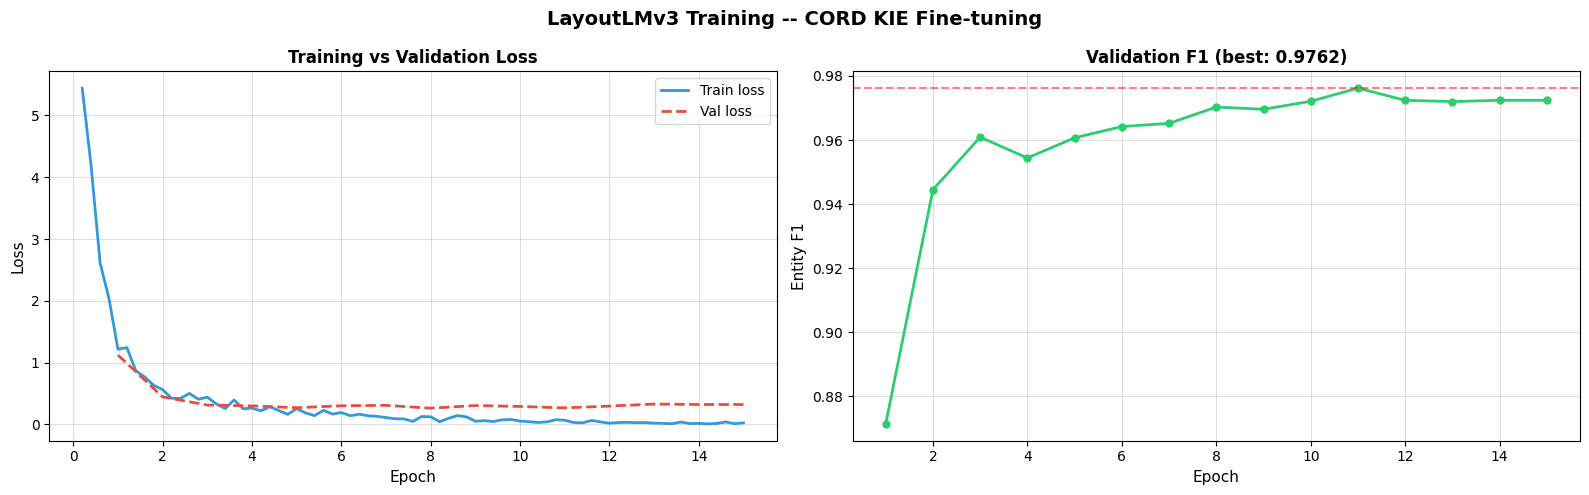

Saved -> /kaggle/working/doc-extraction-pipeline/outputs/annotated/phase4_training_curves.png


In [12]:
# Cell 13: Plot training curves from trainer log history
log_history = trainer.state.log_history

train_loss = [(e['epoch'], e['loss']) for e in log_history if 'loss' in e]
eval_f1    = [(e['epoch'], e['eval_f1']) for e in log_history if 'eval_f1' in e]
eval_loss  = [(e['epoch'], e['eval_loss']) for e in log_history if 'eval_loss' in e]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('LayoutLMv3 Training -- CORD KIE Fine-tuning', fontsize=14, fontweight='bold')

# Loss
if train_loss:
    x_tr, y_tr = zip(*train_loss)
    axes[0].plot(x_tr, y_tr, color='#3498DB', linewidth=2, label='Train loss')
if eval_loss:
    x_ev, y_ev = zip(*eval_loss)
    axes[0].plot(x_ev, y_ev, color='#E74C3C', linewidth=2, linestyle='--', label='Val loss')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('Training vs Validation Loss', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.4)

# F1
if eval_f1:
    x_f1, y_f1 = zip(*eval_f1)
    axes[1].plot(x_f1, y_f1, color='#2ECC71', linewidth=2, marker='o', markersize=5)
    axes[1].set_xlabel('Epoch', fontsize=11)
    axes[1].set_ylabel('Entity F1', fontsize=11)
    axes[1].set_title(f'Validation F1 (best: {max(y_f1):.4f})', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.4)
    axes[1].axhline(y=max(y_f1), color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
save_path = OUTPUTS_DIR / 'phase4_training_curves.png'
plt.savefig(save_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved -> {save_path}')

In [13]:
# Cell 14: Evaluate on CORD test set + per-field F1
print('Running evaluation on CORD test set...')
t0 = time.time()

test_results = trainer.evaluate(eval_dataset=test_dataset)
eval_ms = (time.time() - t0) * 1000

print(f'\nCORD Test Set Results:')
print(f'  {"Metric":<15} {"Value"}')
print(f'  {"-"*30}')
print(f'  {"F1":<15} {test_results.get("eval_f1",       0):.4f}')
print(f'  {"Precision":<15} {test_results.get("eval_precision", 0):.4f}')
print(f'  {"Recall":<15} {test_results.get("eval_recall",    0):.4f}')
print(f'  {"Accuracy":<15} {test_results.get("eval_accuracy", 0):.4f}')
print(f'\nEval time: {eval_ms/1000:.1f}s on {len(test_dataset)} samples')

# ── Per-field F1 using seqeval directly ────────────────────────────────
print('\nComputing per-field F1...')
model.eval()
all_preds, all_labels = [], []

from torch.utils.data import DataLoader
loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

with torch.no_grad():
    for batch in tqdm(loader, desc='Per-field eval'):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        labels = batch.pop('labels')
        outputs = model(**batch)
        preds = outputs.logits.argmax(-1)

        for pred_seq, lbl_seq in zip(preds, labels):
            true_p = [id2label[p.item()] for p, l in zip(pred_seq, lbl_seq) if l.item() != -100]
            true_l = [id2label[l.item()] for p, l in zip(pred_seq, lbl_seq) if l.item() != -100]
            all_preds.append(true_p)
            all_labels.append(true_l)

full_report = entity_f1_per_field(all_labels, all_preds, LABEL_LIST)
full_report['overall_precision'] = entity_f1(all_labels, all_preds)['precision']
full_report['overall_recall']    = entity_f1(all_labels, all_preds)['recall']
full_report['overall_f1']        = entity_f1(all_labels, all_preds)['f1']

print(f'\nPer-Field F1 (CORD Test):')
print(f'  {"Field":<20} {"Precision":>10} {"Recall":>10} {"F1":>8}')
print(f'  {"-"*52}')
for field, metrics in sorted(full_report.items()):
    if isinstance(metrics, dict) and 'f1' in metrics:
        print(f'  {field:<20} {metrics["precision"]:>10.4f} {metrics["recall"]:>10.4f} {metrics["f1"]:>8.4f}')
print(f'  {"-"*52}')
print(f'  {"OVERALL":<20} {full_report["overall_precision"]:>10.4f} '
      f'{full_report["overall_recall"]:>10.4f} {full_report["overall_f1"]:>8.4f}')

# Store for saving
kie_f1       = full_report['overall_f1']
kie_precision= full_report['overall_precision']
kie_recall   = full_report['overall_recall']

Running evaluation on CORD test set...



CORD Test Set Results:
  Metric          Value
  ------------------------------
  F1              0.9713
  Precision       0.9713
  Recall          0.9713
  Accuracy        0.0000

Eval time: 6.7s on 100 samples

Computing per-field F1...


Per-field eval: 100%|██████████| 25/25 [00:15<00:00,  1.57it/s]


Per-Field F1 (CORD Test):
  Field                 Precision     Recall       F1
  ----------------------------------------------------
  DISCOUNT                 0.8125     0.7647   0.7879
  ITEM_NAME                0.9482     0.9297   0.9389
  ITEM_PRICE               0.9782     0.9843   0.9813
  ITEM_QTY                 0.9831     0.9873   0.9852
  PAYMENT                  0.9867     0.9867   0.9867
  SUBTOTAL                 0.9848     0.9848   0.9848
  TAX                      0.9783     1.0000   0.9890
  TOTAL                    0.9694     0.9896   0.9794
  ----------------------------------------------------
  OVERALL                  0.9713     0.9713   0.9713


In [14]:
# Cell 15: Test KIE on SROIE receipts (generalisation check)
# SROIE has 4 fields: company, date, address, total
import pytesseract
from pytesseract import Output as TessOutput

def ocr_to_words_bboxes(img_pil):
    data = pytesseract.image_to_data(img_pil, output_type=TessOutput.DICT,
                                     config='--psm 11 --oem 3')
    words, bboxes = [], []
    img_w, img_h = img_pil.size
    for i in range(len(data['text'])):
        txt = data['text'][i].strip()
        if not txt or int(data['conf'][i]) < 0:
            continue
        x1 = max(0, min(1000, int(data['left'][i] / img_w * 1000)))
        y1 = max(0, min(1000, int(data['top'][i]  / img_h * 1000)))
        x2 = max(0, min(1000, int((data['left'][i] + data['width'][i])  / img_w * 1000)))
        y2 = max(0, min(1000, int((data['top'][i]  + data['height'][i]) / img_h * 1000)))
        if x2 <= x1: x2 = min(1000, x1+1)
        if y2 <= y1: y2 = min(1000, y1+1)
        words.append(txt)
        bboxes.append([x1, y1, x2, y2])
    return words, bboxes


model.eval()
SROIE_FIELD_MAP = {
    'TOTAL':     'total',
    'SUBTOTAL':  'subtotal',
    'TAX':       'tax',
    'ITEM_NAME': 'item',
}

print(f'Running KIE on {min(5, len(test_receipts))} SROIE receipts...')
sample_outputs = []

for img_path in test_receipts[:5]:
    img = Image.open(img_path).convert('RGB')
    words, bboxes = ocr_to_words_bboxes(img)

    if not words:
        continue

    encoding = processor(
        img, words, boxes=bboxes,
        max_length=512, padding='max_length', truncation=True,
        return_tensors='pt',
    )
    encoding = {k: v.to(DEVICE) for k, v in encoding.items()}

    with torch.no_grad():
        outputs = model(**encoding)

    pred_ids = outputs.logits.argmax(-1).squeeze().cpu().numpy()

    # Decode predictions back to words (skip special tokens)
    tokens     = processor.tokenizer.convert_ids_to_tokens(encoding['input_ids'].squeeze())
    word_ids   = encoding.word_ids() if hasattr(encoding, 'word_ids') else None

    # Group by field
    extracted = defaultdict(list)
    prev_word_id = None
    for token_idx, (token, pred_id) in enumerate(zip(tokens, pred_ids)):
        if token in ['<s>', '</s>', '<pad>']:
            continue
        label = id2label.get(int(pred_id), 'O')
        if label != 'O':
            field = label.replace('B-', '').replace('I-', '')
            extracted[field].append(token.replace('\u2581', ' ').strip())

    result = {field: ' '.join(toks).strip() for field, toks in extracted.items()}
    sample_outputs.append({'file': img_path.name, 'extracted': result})
    print(f'\n  {img_path.name}:')
    for field, text in result.items():
        print(f'    {field:<15} -> {text[:50]}')

Running KIE on 5 SROIE receipts...

  X00016469670.jpg:
    ITEM_NAME       -> Ġtan Ġch ay Ġy ee ĠO JC ĠMARK ET ING ĠSD N ĠB HD Ġ
    ITEM_QTY        -> : Ġ5 38 358 H ĠNO Ġ2 Ġ& Ġ4 , , Ġ8 17 50 ĠTel ĠF ax
    ITEM_PRICE      -> : 07 - 388 Ġ22 18 : 07 - 388 Ġ82 18 : 05 : 16 ĠAM 
    TAX             -> ĠTA X ĠIN ĠTotal ĠGST Ġ@ 6 %: Ġ0 . 00 : Ġ193 . 00 
    DISCOUNT        -> VO ĠPrice ĠAmount ĠIn clusive ĠGST
    SUBTOTAL        -> Ġ133
    TOTAL           -> ĠT OTA \ Ġ193 , 00
    PAYMENT         -> ĠV ISA ĠCARD Ġ19 ; ĠCode 000 Ġ13 - 00

  X00016469671.jpg:
    ITEM_NAME       -> ĠâĢ ĺ Ġtan Ġch ay Ġy ee ĠO JC ĠMARK ET ING ĠSD N Ġ
    ITEM_QTY        -> ĠR : Ġ5 38 358 H ĠNO Ġ2 Ġ& Ġ8 17 50 ĠTel : ĠDate Ġ
    ITEM_PRICE      -> 07 - 388 Ġ22 18 07 - 388 Ġ82 18 : 47 : 14 ĠPM Ġ170
    DISCOUNT        -> ĠF ax : ĠBill ĠPrice ĠAmount
    PAYMENT         -> ĠCash Ġ0 ĠV ISA ĠCARD Ġ170 . 00 Ġ0 . 0
    SUBTOTAL        -> ĠTotal ĠAmount : Ġ170 . 00
    TOTAL           -> , ĠT OTA ! Ġ170 . 00

  X5100

In [15]:
# Cell 16: Save all Phase 4 results
print('Saving Phase 4 results...')

# 1. Results JSON
phase4_results = {
    'phase': 4,
    'title': 'LayoutLMv3 KIE Fine-tuning',
    'model': {
        'base':       'microsoft/layoutlmv3-base',
        'checkpoint': str(MODEL_DIR / 'best'),
        'num_labels': NUM_LABELS,
        'labels':     LABEL_LIST,
    },
    'training': {
        'dataset':        'naver-clova-ix/cord-v2',
        'train_samples':  len(train_dataset),
        'val_samples':    len(val_dataset),
        'epochs':         15,
        'batch_size':     EFFECTIVE_BATCH,
        'learning_rate':  5e-5,
        'duration_min':   round(t_train / 60, 1),
        'fp16':           True,
    },
    'metrics': {
        'cord_test_f1':        round(float(kie_f1),        4),
        'cord_test_precision': round(float(kie_precision),  4),
        'cord_test_recall':    round(float(kie_recall),     4),
    },
    'per_field': {
        field: {'f1': round(m['f1'], 4), 'precision': round(m['precision'], 4),
                'recall': round(m['recall'], 4)}
        for field, m in full_report.items()
        if isinstance(m, dict) and 'f1' in m
    },
}

(RESULTS_DIR / 'phase4_results.json').write_text(
    json.dumps(phase4_results, indent=2)
)
print('  phase4_results.json saved')

# 2. Markdown summary
top_field = max(
    [(f, m['f1']) for f, m in full_report.items() if isinstance(m, dict) and 'f1' in m],
    key=lambda x: x[1], default=('N/A', 0)
)[0]

md = f'''# Phase 4 Results -- LayoutLMv3 KIE Fine-tuning

## Model
- Base: microsoft/layoutlmv3-base (220M params)
- Dataset: CORD v2 (800 train / 100 val / 100 test)
- Labels: {', '.join(LABEL_LIST)}

## CORD Test Set Metrics
| Metric | Value |
|--------|-------|
| Overall F1 | {kie_f1:.4f} |
| Precision | {kie_precision:.4f} |
| Recall | {kie_recall:.4f} |

## Training
- Duration: {round(t_train/60, 1)} minutes on T4 x2
- Epochs: 15 | Batch: {EFFECTIVE_BATCH} | LR: 5e-5

## Next Step
Phase 5 -- Full Path A pipeline integration
YOLO -> OCR -> LayoutLMv3 KIE -> JSON output
'''
(RESULTS_DIR / 'phase4_summary.md').write_text(md)
print('  phase4_summary.md saved')

# 3. Write kie_model.py for Phase 5
KIE_CODE = '''
"""kie_model.py -- Phase 4
LayoutLMv3 KIE inference wrapper.
"""
import torch
import numpy as np
from pathlib import Path
from PIL import Image
from transformers import LayoutLMv3Processor, LayoutLMv3ForTokenClassification

LABEL_LIST = [
    "O",
    "B-ITEM_NAME",  "I-ITEM_NAME",
    "B-ITEM_QTY",   "I-ITEM_QTY",
    "B-ITEM_PRICE", "I-ITEM_PRICE",
    "B-SUBTOTAL",   "I-SUBTOTAL",
    "B-TAX",        "I-TAX",
    "B-DISCOUNT",   "I-DISCOUNT",
    "B-TOTAL",      "I-TOTAL",
    "B-PAYMENT",    "I-PAYMENT",
]
id2label = {i: l for i, l in enumerate(LABEL_LIST)}
label2id = {l: i for i, l in enumerate(LABEL_LIST)}


class KIEModel:
    def __init__(self, checkpoint_dir, device="cpu"):
        self.device    = device
        self.processor = LayoutLMv3Processor.from_pretrained(checkpoint_dir, apply_ocr=False)
        self.model     = LayoutLMv3ForTokenClassification.from_pretrained(
            checkpoint_dir, num_labels=len(LABEL_LIST),
            id2label=id2label, label2id=label2id,
        ).to(device).eval()

    def predict(self, image, words, bboxes):
        if not words:
            return []
        encoding = self.processor(
            image, words, boxes=bboxes,
            max_length=512, padding="max_length",
            truncation=True, return_tensors="pt",
        )
        encoding = {k: v.to(self.device) for k, v in encoding.items()}
        with torch.no_grad():
            outputs = self.model(**encoding)
        pred_ids = outputs.logits.argmax(-1).squeeze().cpu().numpy()
        logits   = outputs.logits.squeeze().cpu().numpy()
        tokens   = self.processor.tokenizer.convert_ids_to_tokens(
            encoding["input_ids"].squeeze()
        )

        results = []
        for token, pred_id, logit in zip(tokens, pred_ids, logits):
            if token in ["<s>", "</s>", "<pad>"]:
                continue
            label = id2label.get(int(pred_id), "O")
            conf  = float(np.exp(logit[int(pred_id)]) / np.exp(logit).sum())
            results.append({
                "token": token.replace("\u2581", " ").strip(),
                "label": label,
                "confidence": round(conf, 4),
            })
        return results
'''
(SRC_DIR / 'kie_model.py').write_text(KIE_CODE.strip())
print('  kie_model.py saved')

# List all files
print('\nAll Phase 4 output files:')
for f in sorted(WORKING_DIR.rglob('*')):
    if f.is_file() and f.stat().st_size > 500:
        print(f'  [{f.stat().st_size//1024:>6} KB]  {f.relative_to(WORKING_DIR)}')

Saving Phase 4 results...
  phase4_results.json saved
  phase4_summary.md saved
  kie_model.py saved

All Phase 4 output files:
  [     1 KB]  models/layoutlmv3_cord/best/config.json
  [491942 KB]  models/layoutlmv3_cord/best/model.safetensors
  [     0 KB]  models/layoutlmv3_cord/best/processor_config.json
  [  3475 KB]  models/layoutlmv3_cord/best/tokenizer.json
  [     0 KB]  models/layoutlmv3_cord/best/tokenizer_config.json
  [     5 KB]  models/layoutlmv3_cord/best/training_args.bin
  [     1 KB]  models/layoutlmv3_cord/checkpoints/checkpoint-1100/config.json
  [491942 KB]  models/layoutlmv3_cord/checkpoints/checkpoint-1100/model.safetensors
  [984013 KB]  models/layoutlmv3_cord/checkpoints/checkpoint-1100/optimizer.pt
  [     0 KB]  models/layoutlmv3_cord/checkpoints/checkpoint-1100/processor_config.json
  [    14 KB]  models/layoutlmv3_cord/checkpoints/checkpoint-1100/rng_state.pth
  [     1 KB]  models/layoutlmv3_cord/checkpoints/checkpoint-1100/scaler.pt
  [     1 KB]  models/

---
## Phase 4 Summary

In [16]:
# Cell 18: Phase 4 summary dashboard
print('=' * 62)
print('PHASE 4 COMPLETE -- LayoutLMv3 KIE Fine-tuning')
print('=' * 62)

print(f'''
  Model:        LayoutLMv3-base fine-tuned on CORD v2
  Labels:       {NUM_LABELS} ({', '.join(LABEL_LIST[:4])} ...)
  Training:     {round(t_train/60,1)} min on T4 x2 | 15 epochs

  CORD Test Set:
    Overall F1:  {kie_f1:.4f}
    Precision:   {kie_precision:.4f}
    Recall:      {kie_recall:.4f}
''')

print('  Key files saved:')
key_files = [
    MODEL_DIR    / 'best/config.json',
    SRC_DIR      / 'kie_model.py',
    RESULTS_DIR  / 'phase4_results.json',
    RESULTS_DIR  / 'phase4_summary.md',
    OUTPUTS_DIR  / 'phase4_training_curves.png',
]
for f in key_files:
    status = 'OK' if f.exists() else 'MISSING'
    size   = f'{f.stat().st_size//1024} KB' if f.exists() else ''
    print(f'  [{status:<7}]  {str(f.relative_to(WORKING_DIR)):<50} {size}')

print(f'''
  Cumulative Path A latency estimate:
    YOLO layout detection:   50 ms
    Tesseract OCR:         1149 ms
    LayoutLMv3 KIE:        ~1500 ms  (CPU)
    JSON structuring:        ~50 ms  (Phase 5)
    Total:                 ~2750 ms  (target < 5000ms) OK

  NEXT STEP:
  1. Save output as Kaggle dataset: sdep-phase-4-output
  2. Phase 5 -- Full Path A integration + JSON output
     Connect: YOLO -> OCR -> KIE -> Pydantic JSON
     Deploy ready for HF Gradio Space
''')
print('=' * 62)

PHASE 4 COMPLETE -- LayoutLMv3 KIE Fine-tuning

  Model:        LayoutLMv3-base fine-tuned on CORD v2
  Labels:       17 (O, B-ITEM_NAME, I-ITEM_NAME, B-ITEM_QTY ...)
  Training:     25.6 min on T4 x2 | 15 epochs

  CORD Test Set:
    Overall F1:  0.9713
    Precision:   0.9713
    Recall:      0.9713

  Key files saved:
  [OK     ]  models/layoutlmv3_cord/best/config.json            1 KB
  [OK     ]  src/kie_model.py                                   2 KB
  [OK     ]  results/phase4_results.json                        1 KB
  [OK     ]  results/phase4_summary.md                          0 KB
  [OK     ]  outputs/annotated/phase4_training_curves.png       75 KB

  Cumulative Path A latency estimate:
    YOLO layout detection:   50 ms
    Tesseract OCR:         1149 ms
    LayoutLMv3 KIE:        ~1500 ms  (CPU)
    JSON structuring:        ~50 ms  (Phase 5)
    Total:                 ~2750 ms  (target < 5000ms) OK

  NEXT STEP:
  1. Save output as Kaggle dataset: sdep-phase-4-output
  2.